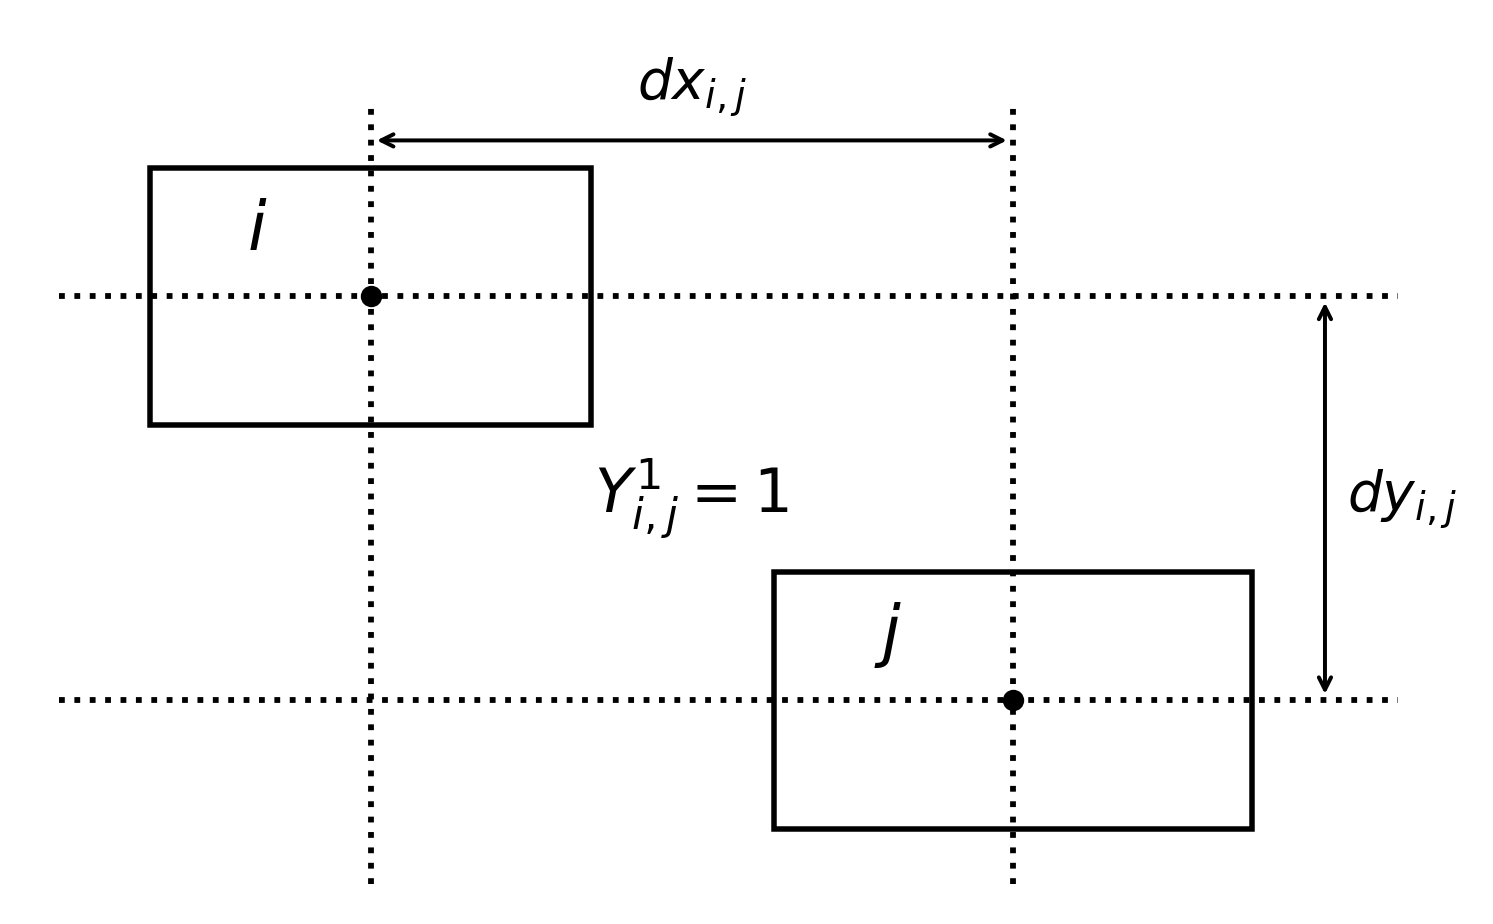

\begin{gather}
\min \; \lambda\,(l_f + w_f) + \sum_{i,j} c_{i,j}( dx_{i,j} + dy_{i,j}) \\
\text{Minimize the weighted plant size plus cost-weighted rectilinear pipe distances ($\lambda = 1$ by default)}\\
\textrm{s.t.} \;l_f \ge y_i + l_i \; \forall  i \in  N \\
\text{Plant length (the vertical $y$ axis) contains every block}\\
w_f \ge x_i + w_i \; \forall  i \in  N \\
\text{Plant width (the horizontal $x$ axis) contains every block}\\
y_1 = 0, \quad l_f = l_1 \\
\text{The pipe rack (block 1) spans the plant length: pinned at $y=0$ with the plant length fixed to the rack}\\
x_h = x_1 \;\; \forall h \in H, \quad y_{h_N} = l_f, \quad y_{h_S} = 0 \\
\text{The two zero-length tie-in headers $H = \{h_N, h_S\}$ sit flush on the rack's north and south ends}\\
dx_{i,j} \ge \left(x_i + \tfrac{w_i}{2}\right) - \left(x_j + \tfrac{w_j}{2}\right), \quad dx_{i,j} \ge \left(x_j + \tfrac{w_j}{2}\right) - \left(x_i + \tfrac{w_i}{2}\right) \; \forall i,j \in N,\, j<i \\
dy_{i,j} \ge \left(y_i + \tfrac{l_i}{2}\right) - \left(y_j + \tfrac{l_j}{2}\right), \quad dy_{i,j} \ge \left(y_j + \tfrac{l_j}{2}\right) - \left(y_i + \tfrac{l_i}{2}\right) \; \forall i,j \in N,\, j<i \\
\text{Rectilinear center-to-center distances, defined globally, not inside the disjunction}\\
x_i \le UB, \; y_i \le UB \; \forall i \in  N, \quad UB = \sum_{i} \max(l_i,w_i) \\
\left[
\begin{array}{c}
Y_{i,j}^1\\
x_i + w_i + d_{i,j} \le x_j\\
y_i + l_i \ge y_j - d_{i,j}\\
y_j + l_j \ge y_i - d_{i,j}\\
\text{$i$ is left of $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^2\\
x_j + w_j + d_{i,j} \le x_i\\
y_i + l_i \ge y_j - d_{i,j}\\
y_j + l_j \ge y_i - d_{i,j}\\
\text{$i$ is right of $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^3 \\
y_i + l_i + d_{i,j} \le y_j \\
\text{$i$ is below $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^4 \\
y_j + l_j + d_{i,j} \le y_i \\
\text{$i$ is above $j$}
\end{array}
\right] \\
\text{Non-overlap: one separation per pair, with the minimum clearance $d_{i,j}$ built in ($d_{i,j} = 0$ on header pairs). The left/right disjuncts also force vertical overlap within $d_{i,j}$ (a degeneracy breaking constraint)}\\
\\
\left[
\begin{array}{c}
Y_{i}^5 \\
l_i = l^0_i \\
w_i = w^0_i\\
\text{Default orientation}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i}^6\\
l_i = w^0_i \\
w_i = l^0_i \\
\text{Rotated orientation}
\end{array}
\right] \; \forall i \in N \setminus (\{1\} \cup H) \\
\\
l_f,w_f,l_i,w_i,x_i,y_i,dx_{i,j},dy_{i,j} \in \mathbb{R}^1_+ \\
Y_{i,j}^1,Y_{i,j}^2,Y_{i,j}^3,Y_{i,j}^4,Y_{i}^5,Y_{i}^6 \in \text{ \{ True, False \}  } \\
\forall i,j \in N, j <i
\end{gather}

Length is the vertical ($y$) axis and width the horizontal ($x$) axis. Distances are **center-to-center rectilinear** (the process-plant layout literature convention), defined by the global $dx,dy$ constraints, so the disjunction decides only non-overlap, never cost. This keeps the objective independent of which spatial relation is chosen. The pipe costs $c_{i,j}$ carry two kinds of connection: each unit pipes to the tie-in header at its assigned north or south rack end, and a few close-coupled unit pairs pipe directly to each other. The headers are virtual pipe targets, not physical equipment, so every pair involving a header has $d_{i,j} = 0$.

The left/right disjuncts additionally force the two blocks to overlap vertically within $d_{i,j}$. This is a **degeneracy breaking constraint**, the $d$-aware, continuous-valid form of Trespalacios & Grossmann. A diagonally separated pair (vertical gap $> d_{i,j}$) can then only be encoded as above/below, so each physical layout has essentially one encoding, and it is what makes the app's solution pool return distinct layouts rather than duplicate indicator encodings of one layout. The offset must be $-d_{i,j}$, not the tighter $-(d_{i,j}-1)$: the $d-1$ form is only optimum-preserving when an integer-optimal layout is guaranteed, which the center-to-center objective breaks for odd dimensions (centers can be optimal at half-integers).

The rack keeps a fixed orientation even when rotation is on, so the rotation disjunction applies to the real non-rack blocks only. Symmetry breaking (when `sym=1`) anchors block 1 left of block 2's center: $x_1 + w_1/2 \le x_2 + w_2/2$. Only the horizontal mirror is a symmetry here: flipping $y$ would swap each unit's north/south tie-in, so there is no vertical cut. The footprint weight $\lambda$ defaults to 1. Raise it to favor a smaller plant over cheaper piping.

In [1]:
import random

import pandas as pd
import pyomo.environ as pyo
from pyomo.gdp import Disjunction


def build_model(n, l0, w0, cmat, d_uniform, rotate, sym):
    """The app's model, verbatim from app.py."""
    m = pyo.ConcreteModel()

    # Blocks indexed 1..n; pair set is the strict lower triangle (i > j).
    m.n = pyo.Set(ordered=True, initialize=pyo.RangeSet(1, n))
    m.p = pyo.Set(initialize=m.n * m.n, dimen=2,
                  filter=lambda m, i, j: i > j)

    # Default-orientation dimensions.
    m.w0 = pyo.Param(m.n, initialize=w0)
    m.l0 = pyo.Param(m.n, initialize=l0)

    # Pair parameters: pipe cost and minimum required separation. Tie-in
    # headers (zero-length objects) are virtual pipe targets, not physical
    # equipment, so every pair involving a header gets zero minimum distance.
    c_dict = {(i, j): float(cmat[i - 1][j - 1]) for i, j in m.p}
    d_dict = {(i, j): float(d_uniform) for i, j in m.p}
    _hdr = {i for i in m.n if l0[i] == 0}
    for (i, j) in d_dict:
        if i in _hdr or j in _hdr:
            d_dict[(i, j)] = 0.0
    m.c = pyo.Param(m.p, initialize=c_dict)
    m.d = pyo.Param(m.p, initialize=d_dict)

    # Conservative upper bound on placement coordinates.
    m.UB = pyo.Param(initialize=sum(max(m.l0[i], m.w0[i]) for i in m.n))

    m.x = pyo.Var(m.n, bounds=(0, m.UB))      # lower-left x
    m.y = pyo.Var(m.n, bounds=(0, m.UB))      # lower-left y
    m.l = pyo.Var(m.n, bounds=(0, m.UB))      # block length (= l0 unless rotated)
    m.w = pyo.Var(m.n, bounds=(0, m.UB))      # block width  (= w0 unless rotated)
    m.dx = pyo.Var(m.p, bounds=(0, m.UB))     # center-to-center x distance
    m.dy = pyo.Var(m.p, bounds=(0, m.UB))     # center-to-center y distance
    m.l_f = pyo.Var(within=pyo.NonNegativeReals)  # plant length
    m.w_f = pyo.Var(within=pyo.NonNegativeReals)  # plant width

    # Plant bounds: every block lies inside the plant's bounding box.
    @m.Constraint(m.n)
    def plant_length(m, i):
        return m.l_f >= m.y[i] + m.l[i]

    @m.Constraint(m.n)
    def plant_width(m, i):
        return m.w_f >= m.x[i] + m.w[i]

    # Pipe rack (block 1) spans the plant length: pinned at y=0 with the
    # plant length fixed to the rack's length.
    m.rack_at_origin = pyo.Constraint(expr=m.y[1] == 0)
    m.plant_len_eq_rack = pyo.Constraint(expr=m.l_f == m.l[1])

    # Implicit pipe-rack tie-in headers: each zero-length object is pinned
    # flush to one end of the main rack and aligned to its x.
    _headers = sorted(i for i in m.n if l0[i] == 0)
    if len(_headers) >= 1:
        _hn = _headers[0]
        m.pin_north_x = pyo.Constraint(expr=m.x[_hn] == m.x[1])
        m.pin_north_y = pyo.Constraint(expr=m.y[_hn] == m.l_f)
    if len(_headers) >= 2:
        _hs = _headers[1]
        m.pin_south_x = pyo.Constraint(expr=m.x[_hs] == m.x[1])
        m.pin_south_y = pyo.Constraint(expr=m.y[_hs] == 0)

    # Rectilinear center-to-center distances, defined GLOBALLY (not inside
    # the disjunction): the literature-standard distance convention. They're
    # minimized in the objective, so each settles to the true center distance.
    @m.Constraint(m.p)
    def dx_lb_a(m, i, j):
        return m.dx[i, j] >= (m.x[i] + m.w[i] / 2) - (m.x[j] + m.w[j] / 2)

    @m.Constraint(m.p)
    def dx_lb_b(m, i, j):
        return m.dx[i, j] >= (m.x[j] + m.w[j] / 2) - (m.x[i] + m.w[i] / 2)

    @m.Constraint(m.p)
    def dy_lb_a(m, i, j):
        return m.dy[i, j] >= (m.y[i] + m.l[i] / 2) - (m.y[j] + m.l[j] / 2)

    @m.Constraint(m.p)
    def dy_lb_b(m, i, j):
        return m.dy[i, j] >= (m.y[j] + m.l[j] / 2) - (m.y[i] + m.l[i] / 2)

    # Symmetry breaking: anchor block 1 left-of block 2's center, killing the
    # left/right mirror. Only the horizontal mirror is a symmetry here: the
    # top/bottom mirror is NOT, because flipping y would swap each object's
    # north/south tie-in.
    if sym == 1:
        @m.Constraint()
        def sym_1(m):
            return m.x[1] + m.w[1] / 2 <= m.x[2] + m.w[2] / 2

    # Objective: minimize plant size + sum of pipe-weighted distances.
    m.obj = pyo.Objective(
        expr=FOOTPRINT_WEIGHT * (m.l_f + m.w_f)
             + sum(m.c[i, j] * (m.dx[i, j] + m.dy[i, j]) for i, j in m.p),
        sense=pyo.minimize,
    )

    # Non-overlap GDP: 4-way disjunction per pair, one spatial relation each
    # with the minimum separation d baked in.
    #
    # Degeneracy breaking constraint (d-aware Trespalacios & Grossmann,
    # continuous-valid form): the left/right disjuncts additionally require
    # the blocks to overlap vertically within d, so a pair with vertical gap
    # > d can only route through above/below: one encoding per physical
    # layout. The offset must be -d, not the tighter -(d-1): the d-1 form is
    # only optimum-preserving when an integer-optimal layout is guaranteed,
    # which the center-to-center objective breaks for odd dimensions.
    @m.Disjunction(m.p)
    def no_overlap(m, i, j):
        vov = [m.y[i] + m.l[i] >= m.y[j] - m.d[i, j],
               m.y[j] + m.l[j] >= m.y[i] - m.d[i, j]]
        return [
            [m.x[i] + m.w[i] + m.d[i, j] <= m.x[j]] + vov,   # i left of j
            [m.x[j] + m.w[j] + m.d[i, j] <= m.x[i]] + vov,   # i right of j
            [m.y[i] + m.l[i] + m.d[i, j] <= m.y[j]],         # i below j
            [m.y[j] + m.l[j] + m.d[i, j] <= m.y[i]],         # i above j
        ]

    # Rotation GDP (optional): 2-way disjunction per block, EXCEPT the rack
    # and the zero-length tie-in headers, which keep a fixed orientation.
    if rotate:
        _rot_blocks = [i for i in m.n if i != 1 and l0[i] != 0]

        @m.Disjunction(_rot_blocks)
        def rotation(m, i):
            return [
                [m.l[i] == m.l0[i], m.w[i] == m.w0[i]],   # default
                [m.l[i] == m.w0[i], m.w[i] == m.l0[i]],   # 90 degrees rotated
            ]

        _fixed = [i for i in m.n if i not in _rot_blocks]

        @m.Constraint(_fixed)
        def fix_l(m, i):
            return m.l[i] == m.l0[i]

        @m.Constraint(_fixed)
        def fix_w(m, i):
            return m.w[i] == m.w0[i]
    else:
        @m.Constraint(m.n)
        def fix_l(m, i):
            return m.l[i] == m.l0[i]

        @m.Constraint(m.n)
        def fix_w(m, i):
            return m.w[i] == m.w0[i]

    return m

In [2]:
# The app's default instance: seed 1, the fixed 9x1 pipe rack plus 14 units,
# each with a length, width, pipe cost, and a north/south rack end it ties
# into. Two zero-length tie-in headers are appended as virtual pipe targets.
# On top of the rack tie-ins, a disjoint pairing of the units is rolled from
# an independent seed and the first 3 pairs are active at pipe cost 10 (the
# app's "Connections" and "Cost x" defaults). Same RNG sequences as app.py.
FOOTPRINT_WEIGHT = 1.0
RACK_LEN, RACK_WID = 9, 1
DEFAULT_SEED, DEFAULT_N = 1, 15
DEFAULT_PAIRS, PAIR_WEIGHT = 3, 10
D_DEFAULT = 1


def gen_objects(seed, objs):
    rng = random.Random(seed)
    objs = list(objs)
    rack = objs[0]
    length, width, cost = {rack: RACK_LEN}, {rack: RACK_WID}, {rack: 0}
    for oid in objs[1:]:
        length[oid] = rng.randint(1, 3)
        width[oid] = rng.randint(1, 3)
        cost[oid] = rng.randint(1, 3)
    side = {oid: rng.choice(["N", "S"]) for oid in objs[1:]}
    return objs, length, width, cost, side


def gen_pairs(seed, objs):
    rng = random.Random(seed + 10_000_019)
    units = list(objs[1:])
    rng.shuffle(units)
    return [(units[k], units[k + 1]) for k in range(0, len(units) - 1, 2)]


def objs_to_inputs(objs, length, width, cost, side, pairs):
    nu = len(objs)
    north, south = nu + 1, nu + 2
    n = nu + 2
    l0 = {p: int(length[objs[p - 1]]) for p in range(1, nu + 1)}
    w0 = {p: int(width[objs[p - 1]]) for p in range(1, nu + 1)}
    l0[north] = l0[south] = 0
    w0[north] = w0[south] = RACK_WID
    cmat = [[0.0] * n for _ in range(n)]
    for p in range(2, nu + 1):
        h = north if side[objs[p - 1]] == "N" else south
        cmat[h - 1][p - 1] = float(cost[objs[p - 1]])
    pos = {oid: k + 1 for k, oid in enumerate(objs)}
    for a, b in pairs:
        pa, pb = pos[a], pos[b]
        cmat[max(pa, pb) - 1][min(pa, pb) - 1] += float(PAIR_WEIGHT)
    return n, l0, w0, cmat


objs, length, width, cost, side = gen_objects(DEFAULT_SEED, list(range(1, DEFAULT_N + 1)))
pairs = gen_pairs(DEFAULT_SEED, objs)[:DEFAULT_PAIRS]
n, l0, w0, cmat = objs_to_inputs(objs, length, width, cost, side, pairs)

print(f"{n} blocks (rack + {DEFAULT_N - 1} units + 2 headers)\n")
print(" obj   L   W  cost  side")
for o in objs:
    print(f"{o:>4}  {length[o]:>2}  {width[o]:>2}  {cost[o]:>4}   {side.get(o, '-')}")
print("\nactive unit-to-unit pairs (cost 10 each):", pairs)

17 blocks (rack + 14 units + 2 headers)

 obj   L   W  cost  side
   1   9   1     0   -
   2   1   3     1   N
   3   2   1     2   S
   4   2   2     3   N
   5   2   1     1   N
   6   2   1     2   S
   7   2   3     1   S
   8   3   2     2   N
   9   3   1     3   S
  10   1   2     1   N
  11   1   1     3   N
  12   3   1     2   S
  13   3   1     2   N
  14   3   1     3   S
  15   1   2     2   S

active unit-to-unit pairs (cost 10 each): [(4, 3), (2, 14), (13, 10)]


In [3]:
m = build_model(n, l0, w0, cmat, d_uniform=D_DEFAULT, rotate=False, sym=1)
pyo.TransformationFactory("gdp.bigm").apply_to(m)

# HiGHS is the open-source MILP solver (pip install highspy). The native appsi
# interface respects the time limit and still loads a timed-out incumbent.
# On this instance HiGHS hits the limit with a good incumbent but does not
# prove optimality (even 10 minutes is not enough). The proven optimum is
# 255.5: the app's Gurobi path proves it in seconds, and the pyomo-cp example
# (https://github.com/devin-griff/pyomo-cp) solves the same GDP with CP-SAT
# to proven optimality in about a minute.
from pyomo.contrib.appsi.solvers import Highs

opt = Highs()
opt.config.time_limit = 60
opt.config.load_solution = False
opt.config.stream_solver = True
res = opt.solve(m)
if res.best_feasible_objective is not None:
    res.solution_loader.load_vars()

print("termination:", res.termination_condition)
print("objective:  ", res.best_feasible_objective)

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms


MIP has 1843 rows; 886 cols; 7766 nonzeros; 544 integer variables (544 binary)
Coefficient ranges:
  Matrix  [5e-01, 9e+01]
  Cost    [1e+00, 1e+01]
  Bound   [1e+00, 4e+01]
  RHS     [1e+00, 9e+01]
Presolving model
1593 rows, 568 cols, 4276 nonzeros 0s
1093 rows, 512 cols, 3240 nonzeros 0s
953 rows, 428 cols, 2876 nonzeros 0s
Presolve reductions: rows 953(-890); columns 428(-458); nonzeros 2876(-4890) 

Solving MIP model with:
   953 rows
   428 cols (378 binary, 0 integer, 0 implied int., 50 continuous, 0 domain fixed)
   2876 nonzeros



Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
Src  Proc. InQueue |  Leaves   Expl. | BestBound       BestSol              Gap |   Cuts   InLp Confl. | LpIters     Time

         0       0         0   0.00%   42.5            inf                  inf        0      0      0         0     0.0s
         0       0         0   0.00%   64.5            inf                  inf        0      0      2       238     0.1s


 L       0       0         0   0.00%   206.9245441     289.5             28.52%     9172    386     94      3011     0.9s



0.3% inactive integer columns, restarting
Model after restart has 951 rows, 427 cols (377 bin., 0 int., 0 impl., 50 cont., 0 dom.fix.), and 2870 nonzeros

         0       0         0   0.00%   206.9610748     289.5             28.51%      169      0      0      6443     1.8s
         0       0         0   0.00%   206.9610748     289.5             28.51%      169    120      2      6684     1.8s


...

 L    1519     260       563   0.43%   208.8112592     271.5             23.09%    10041    214   3222    129659    46.0s


      1732     312       637   0.43%   208.8112592     271.5             23.09%     9672    302   3463    147319    53.5s


 L    1823     214       681   0.44%   208.8112592     261.5             20.15%    10196    212   3632    149322    55.0s


      2025     245       762   0.45%   208.8112592     261.5             20.15%     7918    316   3867    162288    60.0s

Solving report
  Status            Time limit reached
  Primal bound      261.5
  Dual bound        208.811259171
  Gap               20.15% (tolerance: 0.01%)
  P-D integral      14.337167903
  Solution status   feasible
                    261.5 (objective)
                    0 (bound viol.)
                    0 (int. viol.)
                    0 (row viol.)
  Timing            60.01
  Max sub-MIP depth 8
  Nodes             2025
  Repair LPs        0
  LP iterations     162288
                    60719 (strong br.)
                    6513 (separation)
                    63631 (heuristics)


termination: TerminationCondition.maxTimeLimit
objective:   261.49999999999966


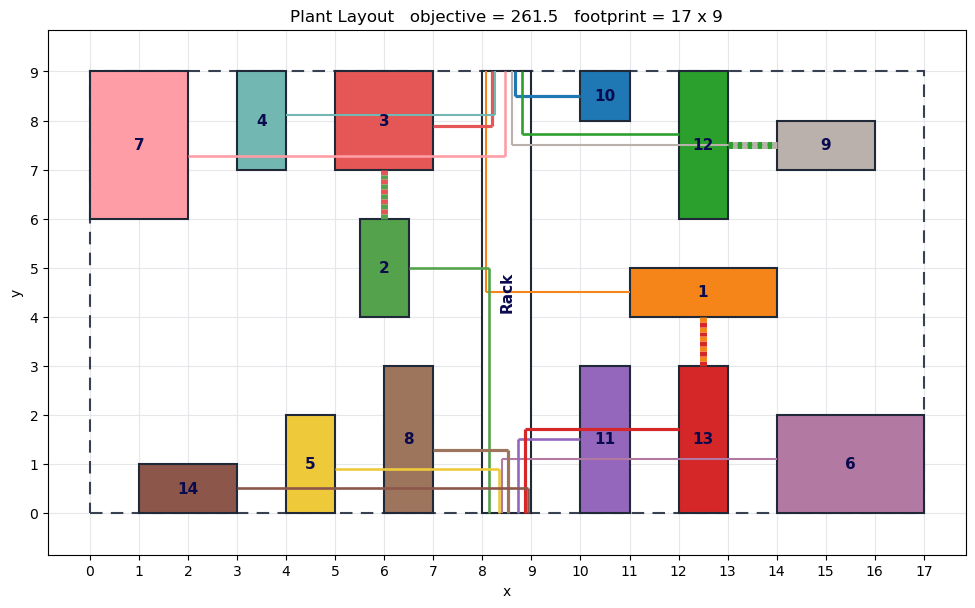

In [4]:
import math

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# The layout, drawn the way the app renders it: palette-colored blocks with a
# white rack, dashed plant bounding box, rack tie-ins threaded through
# per-object lanes, unit-to-unit connections dashed in their two endpoint
# colors, pipe linewidth scaled by cost.
PALETTE = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#EECA3B",
    "#B279A2", "#FF9DA6", "#9D755D", "#BAB0AC", "#1F77B4", "#9467BD",
    "#2CA02C", "#D62728", "#8C564B", "#E377C2", "#17BECF", "#BCBD22",
    "#AEC7E8", "#FFBB78", "#98DF8A", "#C5B0D5", "#C49C94", "#7F7F7F",
    "#DBDB8D",
]

val = pyo.value
blocks = {i: {"x": val(m.x[i]), "y": val(m.y[i]),
              "w": val(m.w[i]), "l": val(m.l[i])} for i in m.n}
headers = {i for i in m.n if l0[i] == 0}
l_f, w_f = val(m.l_f), val(m.w_f)
color = {i: "#ffffff" if i == 1 else PALETTE[(i - 1) % len(PALETTE)]
         for i in m.n}

# Every pair with a pipe: (i, j) has i > j, so tie-in pairs lead with the
# header. Linewidth scales with pipe cost, matching the app's 1.5-5 px range.
pipes = [(i, j, val(m.c[i, j])) for (i, j) in m.p if val(m.c[i, j]) > 0]
c_lo, c_hi = (min(c for *_, c in pipes), max(c for *_, c in pipes))


def lw(c):
    return 2.5 if c_hi == c_lo else 1.5 + 3.5 * (c - c_lo) / (c_hi - c_lo)


def elbow(bi, bj):
    """The app's stylized face-to-face elbow between two blocks: leave block
    i at the midline of the face toward block j, run to block j's center
    coordinate, enter j through the middle of a face. One or two segments."""
    xi, yi, wi, li = bi["x"], bi["y"], bi["w"], bi["l"]
    xj, yj, wj, lj = bj["x"], bj["y"], bj["w"], bj["l"]
    cx_i, cy_i = xi + wi / 2, yi + li / 2
    cx_j, cy_j = xj + wj / 2, yj + lj / 2
    if (xi + wi <= xj) or (xj + wj <= xi):        # disjoint in x
        src_x = xi + wi if cx_j > cx_i else xi
        if yj <= cy_i <= yj + lj:
            dst_x = xj if cx_j > cx_i else xj + wj
            return [(src_x, cy_i, dst_x, cy_i)]
        dst_y = yj if cy_i < yj else yj + lj
        return [(src_x, cy_i, cx_j, cy_i), (cx_j, cy_i, cx_j, dst_y)]
    src_y = yi + li if cy_j > cy_i else yi        # disjoint in y
    if xj <= cx_i <= xj + wj:
        dst_y = yj if cy_j > cy_i else yj + lj
        return [(cx_i, src_y, cx_i, dst_y)]
    dst_x = xj if cx_i < xj else xj + wj
    return [(cx_i, src_y, cx_i, cy_j), (cx_i, cy_j, dst_x, cy_j)]


fig, ax = plt.subplots(figsize=(10, 6))

# Plant bounding box (dashed), then the blocks. Headers are virtual pipe
# targets, not physical equipment: they are not drawn.
ax.add_patch(Rectangle((0, 0), w_f, l_f, fill=False, edgecolor="#374151",
                       lw=1.5, ls=(0, (6, 4)), zorder=1))
for i, b in blocks.items():
    if i in headers:
        continue
    ax.add_patch(Rectangle((b["x"], b["y"]), b["w"], b["l"],
                           facecolor=color[i], edgecolor="#1f2937",
                           lw=1.5, zorder=2))

# Rack tie-ins: a horizontal feeder from the unit's rack-facing edge to its
# own lane inside the rack, then a vertical run along the lane to the
# assigned end (north = l_f, south = 0). Lanes fan the runs across the
# rack's width; feeders sharing a height stagger into a small band.
rack = blocks[1]
rx, rw = rack["x"], rack["w"]
tie_ins = sorted(j for i, j, c in pipes if i in headers)
lane_x = {o: rx + rw * (k + 1) / (len(tie_ins) + 1)
          for k, o in enumerate(tie_ins)}
groups = {}
for o in tie_ins:
    b = blocks[o]
    groups.setdefault(round(b["y"] + b["l"] / 2, 2), []).append(o)
feeder_y = {}
for yc, members in groups.items():
    members.sort(key=lambda o: lane_x[o])
    for k, o in enumerate(members):
        b = blocks[o]
        y = yc + (k - (len(members) - 1) / 2) * 0.22
        feeder_y[o] = min(max(y, b["y"] + 0.05), b["y"] + b["l"] - 0.05)

for h, o, c in ((i, j, c) for i, j, c in pipes if i in headers):
    b = blocks[o]
    y_c = feeder_y[o]
    edge_x = b["x"] if b["x"] >= rx + rw else b["x"] + b["w"]
    ax.plot([edge_x, lane_x[o]], [y_c, y_c], color=color[o], lw=lw(c),
            solid_capstyle="butt", zorder=3)
    ax.plot([lane_x[o]] * 2, [y_c, blocks[h]["y"]], color=color[o], lw=lw(c),
            solid_capstyle="butt", zorder=3)

# Unit-to-unit pipes: elbow path in short dashes alternating the two
# endpoint colors, so the connection reads as belonging to both ends.
DASH = 0.1
for i, j, c in pipes:
    if i in headers:
        continue
    k = 0
    for x1, y1, x2, y2 in elbow(blocks[i], blocks[j]):
        n_dash = max(1, math.ceil((abs(x2 - x1) + abs(y2 - y1)) / DASH))
        for s in range(n_dash):
            t0, t1 = s / n_dash, (s + 1) / n_dash
            ax.plot([x1 + t0 * (x2 - x1), x1 + t1 * (x2 - x1)],
                    [y1 + t0 * (y2 - y1), y1 + t1 * (y2 - y1)],
                    color=color[i] if k % 2 == 0 else color[j], lw=lw(c),
                    solid_capstyle="butt", zorder=3)
            k += 1

# Labels on top: the rack's reads along its tall, thin bar.
for i, b in blocks.items():
    if i in headers:
        continue
    ax.text(b["x"] + b["w"] / 2, b["y"] + b["l"] / 2,
            "Rack" if i == 1 else str(i - 1),
            ha="center", va="center", fontsize=11, fontweight="bold",
            color="#0a0a4e", rotation=90 if i == 1 else 0, zorder=4)

pad = 0.05 * max(l_f, w_f, 1.0)
ax.set_xlim(-pad, w_f + pad)
ax.set_ylim(-pad, l_f + pad)
ax.set_aspect("equal", adjustable="box")
ax.set_xticks(range(int(w_f) + 1))
ax.set_yticks(range(int(l_f) + 1))
ax.grid(True, color="#e5e7eb", lw=0.8)
ax.set_axisbelow(True)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Plant Layout   objective = {val(m.obj):g}   "
             f"footprint = {w_f:g} x {l_f:g}")
plt.tight_layout()
plt.show()

In [5]:
# Block placements (headers excluded: they are pinned to the rack's ends).
pd.DataFrame([{
    "block": "Rack" if i == 1 else str(i - 1),
    "x": val(m.x[i]),
    "y": val(m.y[i]),
    "width": val(m.w[i]),
    "length": val(m.l[i]),
} for i in m.n if l0[i] > 0]).round(2)

,block,x,y,width,length
0,Rack,8.0,0.0,1.0,9.0
1,1,11.0,4.0,3.0,1.0
2,2,5.5,4.0,1.0,2.0
3,3,5.0,7.0,2.0,2.0
4,4,3.0,7.0,1.0,2.0
5,5,4.0,0.0,1.0,2.0
6,6,14.0,0.0,3.0,2.0
7,7,-0.0,6.0,2.0,3.0
8,8,6.0,0.0,1.0,3.0
9,9,14.0,7.0,2.0,1.0
